In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score
df = pd.read_csv('KaggleV2-May-2016.csv')
print(df.shape)



(110527, 14)


In [2]:

df['No-show'].value_counts()
df['Age'].describe()
if df['Age'].min() < 0:
    df.drop(df[df['Age'] < 0].index, inplace=True) #it is dropping all negative age values
df['Handcap'].value_counts()
df['Handicap_flag']=(df['Handcap']!=0).astype(int)# this would create true/false for handcap since 108285 entries were not disease and combining all the handicap entries were giving approx 2000 the model wont learn much from the rare 3s and 4s

"""pd.crosstab(df['Gender'],df['No-show'],normalize='index')# This is done to check if gender truly matters in the no show up if there percentages are equal M/F than this mean they barely contribues to the data so we can drop them   
#ran and found out 0.796% female showed up while 0.80% male showed so this amount of diff is basically noise.

#Doing the same for others
pd.crosstab(df['Scholarship'],df['No-show'],normalize='index')#0.04 diff
pd.crosstab(df['Hipertension'],df['No-show'],normalize='index')#0.03 diff 
pd.crosstab(df['Diabetes'],df['No-show'],normalize='index')#0.02 diff 
pd.crosstab(df['Alcoholism'],df['No-show'],normalize='index')#practically the same
pd.crosstab(df['Handicap_flag'],df['No-show'],normalize='index')#almost 0.02 diff 
pd.crosstab(df['SMS_received'],df['No-show'],normalize='index')# 0.11 difference """

df['ScheduledDay']=pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay']=pd.to_datetime(df['AppointmentDay'])
df.info()

#Okay so waiting days can affect the no show up so we create a colum
df['WaitingDays']=(df['AppointmentDay'].dt.normalize()-df['ScheduledDay'].dt.normalize()).dt.days# sets the time to 00:00 for same days scheduled and appointment to avoid negative values
df['WaitingDays'].describe()
df[df['WaitingDays']<0].shape # gives only 5 rows with negative values safe to drop
df.drop(df[df['WaitingDays']<0].index, inplace=True)

<class 'pandas.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110526 non-null  float64            
 1   AppointmentID   110526 non-null  int64              
 2   Gender          110526 non-null  str                
 3   ScheduledDay    110526 non-null  datetime64[us, UTC]
 4   AppointmentDay  110526 non-null  datetime64[us, UTC]
 5   Age             110526 non-null  int64              
 6   Neighbourhood   110526 non-null  str                
 7   Scholarship     110526 non-null  int64              
 8   Hipertension    110526 non-null  int64              
 9   Diabetes        110526 non-null  int64              
 10  Alcoholism      110526 non-null  int64              
 11  Handcap         110526 non-null  int64              
 12  SMS_received    110526 non-null  int64              
 13  No-show         110526 non-nul

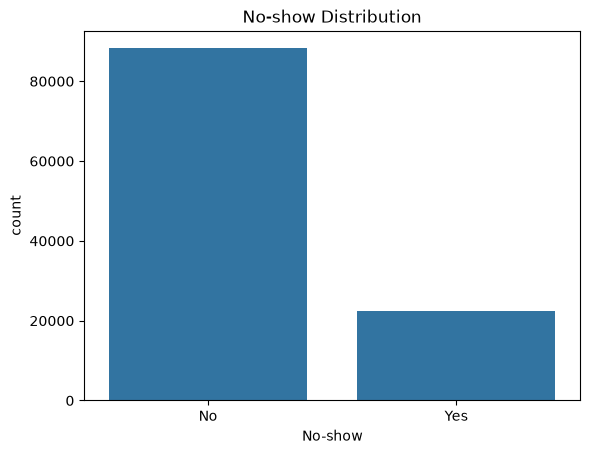

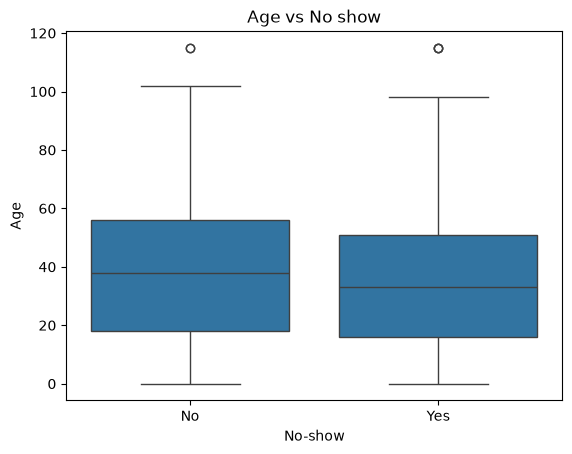

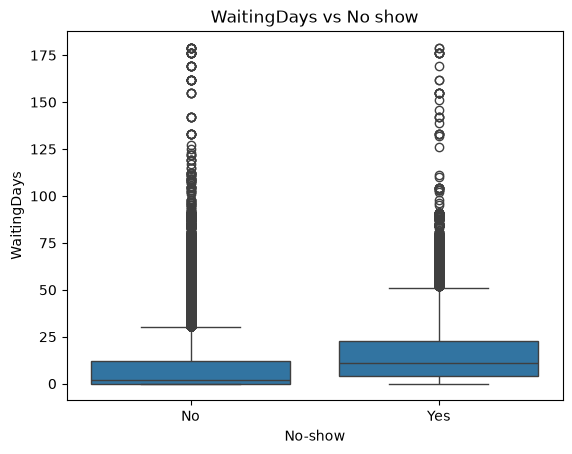

In [3]:

#counting no showups and showups
sns.countplot(x='No-show',data=df)# 80% people showed up and 20% did not show up
plt.title('No-show Distribution')
plt.show()

#Age Vs No show 
sns.boxplot(x='No-show',y='Age',data=df)# see a outlier bw 100 120 
plt.title('Age vs No show')
plt.show()
# Waiting days vs no show
sns.boxplot(x='No-show',y='WaitingDays',data=df)# a lot of outliers some people booked in advance for over 30ish days 
plt.title('WaitingDays vs No show')
plt.show()

In [4]:

df['Gender'].value_counts() # confirmed that there are only F and M values
df['No-show'].value_counts() # confirmed that there are only No and Yes values

df['Gender']=df['Gender'].map({'F': 0, 'M': 1})
df['No-show']=df['No-show'].map({'No':0 , 'Yes':1})
top_neighborhoods=df['Neighbourhood'].value_counts()    .nlargest(10).index
df['Neighbourhood_grouped']=df['Neighbourhood'].where(df['Neighbourhood'].isin(top_neighborhoods),'Others') # 11 total neighbor hood top 10 + sum of all others 
df['AppointmentDayofWeek']=df['AppointmentDay'].dt.day_name()# Since more people are likely so skip weekdays and prefer weekend

X= df.drop(columns=['PatientId','AppointmentID','ScheduledDay','AppointmentDay','Neighbourhood','No-show','Handcap'])
Y=df['No-show']


X=pd.get_dummies(X,columns=['Neighbourhood_grouped','AppointmentDayofWeek'],drop_first=True)# One hot enconding 


In [5]:


Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

model=LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(Xtrain,Ytrain)

Y_predict=model.predict(Xtest) # Predicting on the test data set 
Yproba=model.predict_proba(Xtest)[:,1]# Probality of no show 
print(classification_report(Ytest,Y_predict))
print('ROC AUC score:',roc_auc_score(Ytest,Yproba))



              precision    recall  f1-score   support

           0       0.86      0.69      0.76     17642
           1       0.31      0.56      0.40      4463

    accuracy                           0.66     22105
   macro avg       0.59      0.62      0.58     22105
weighted avg       0.75      0.66      0.69     22105

ROC AUC score: 0.664396312468339


In [6]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=300, # number of tress in the forest
                                class_weight='balanced',# this allows no showup to have a higher penalty than showup cause 80% of the people show up and if model predicts all showup than its alr 80% correct
                                max_depth=None,# full tree
                                random_state=42,
                                n_jobs=1
                                )
rf_model.fit(Xtrain,Ytrain)

rf_predict=rf_model.predict(Xtest)
rf_proba=rf_model.predict_proba(Xtest)[:,1]

print(classification_report(Ytest,rf_predict))
print('ROC score',roc_auc_score(Ytest,rf_proba))


              precision    recall  f1-score   support

           0       0.84      0.76      0.80     17642
           1       0.32      0.45      0.37      4463

    accuracy                           0.70     22105
   macro avg       0.58      0.60      0.59     22105
weighted avg       0.74      0.70      0.71     22105

ROC score 0.6804039146087812


In [7]:
#Comaparing the two Classification models
print("Logistic regression ROC Auc: ",roc_auc_score(Ytest,Yproba))
print("Random Forest Roc Auc",roc_auc_score(Ytest,rf_proba))


Logistic regression ROC Auc:  0.664396312468339
Random Forest Roc Auc 0.6804039146087812


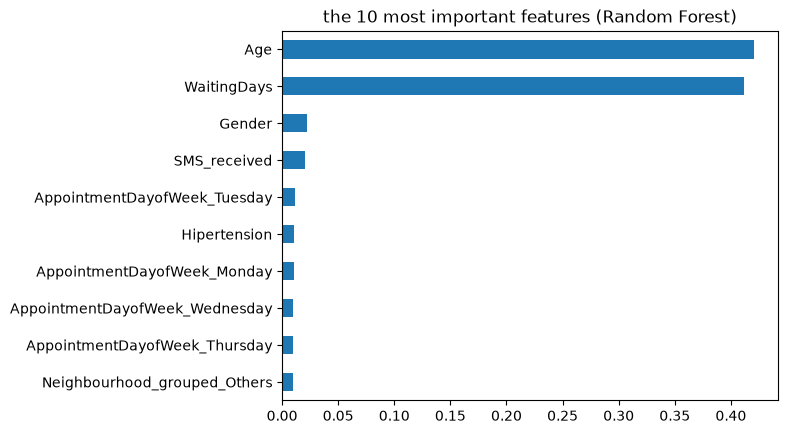

In [8]:
#importance of features
importance=pd.Series(rf_model.feature_importances_,index=Xtrain.columns)
importance=importance.sort_values(ascending=False)

importance.head(10).plot(kind='barh')
plt.title("the 10 most important features (Random Forest)")
plt.gca().invert_yaxis() # ploting so the higheset feature come on top
plt.show()  

In [9]:
df.to_csv('cleaned_appointments.csv', index=False)
